Dataset loaded
Rows: 526 | Wells: 7
Years: 2007–2016
Active rows: 298
Producing wells: 6
Saved cleaned dataset


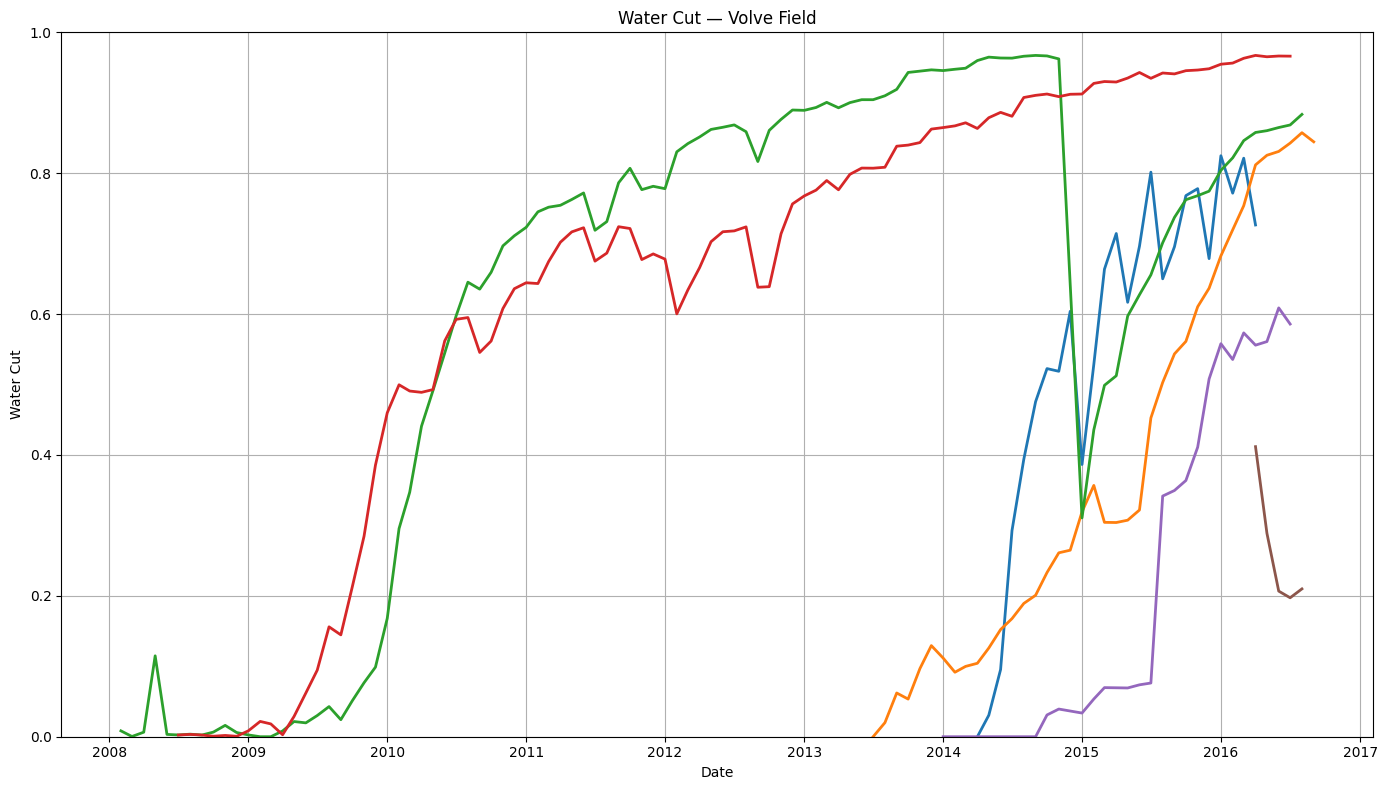


Detected breakthrough events:
      Date Wellbore name  Water_Cut  WC_Change  Oil_Change      Type
2014-07-01    15/9-F-1 C   0.292737   0.197355    -4532.08    Sudden
2014-08-01    15/9-F-1 C   0.393885   0.101148    -8115.25    Sudden
2014-09-01    15/9-F-1 C   0.475671   0.081786     2198.00 Sustained
2014-10-01    15/9-F-1 C   0.522609   0.046938      299.63 Sustained
2014-11-01    15/9-F-1 C   0.518785  -0.003824    -2757.73 Sustained
2014-12-01    15/9-F-1 C   0.603957   0.085172    -6590.04 Sustained
2015-01-01    15/9-F-1 C   0.386476  -0.217482    10755.24 Sustained
2015-02-01    15/9-F-1 C   0.528486   0.142010    -1288.89 Sustained
2015-03-01    15/9-F-1 C   0.663788   0.135302    -3707.42 Sustained
2015-04-01    15/9-F-1 C   0.714384   0.050595    -1955.04 Sustained
2015-05-01    15/9-F-1 C   0.616737  -0.097647      -91.49 Sustained
2015-06-01    15/9-F-1 C   0.696336   0.079599     2511.81 Sustained
2015-07-01    15/9-F-1 C   0.801488   0.105151    -4250.55 Sustained
201

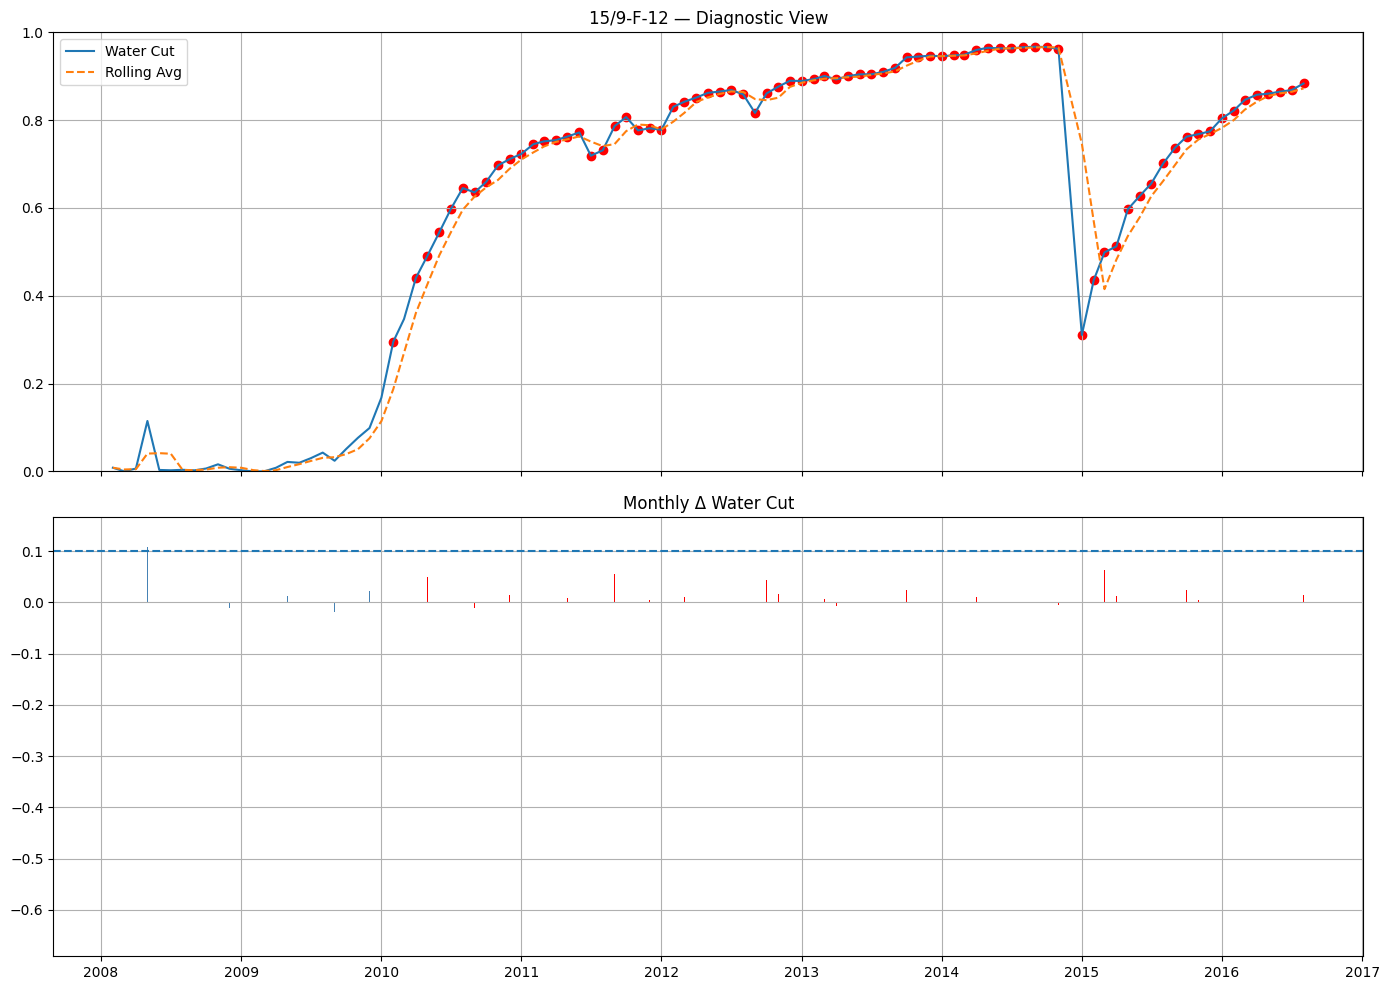

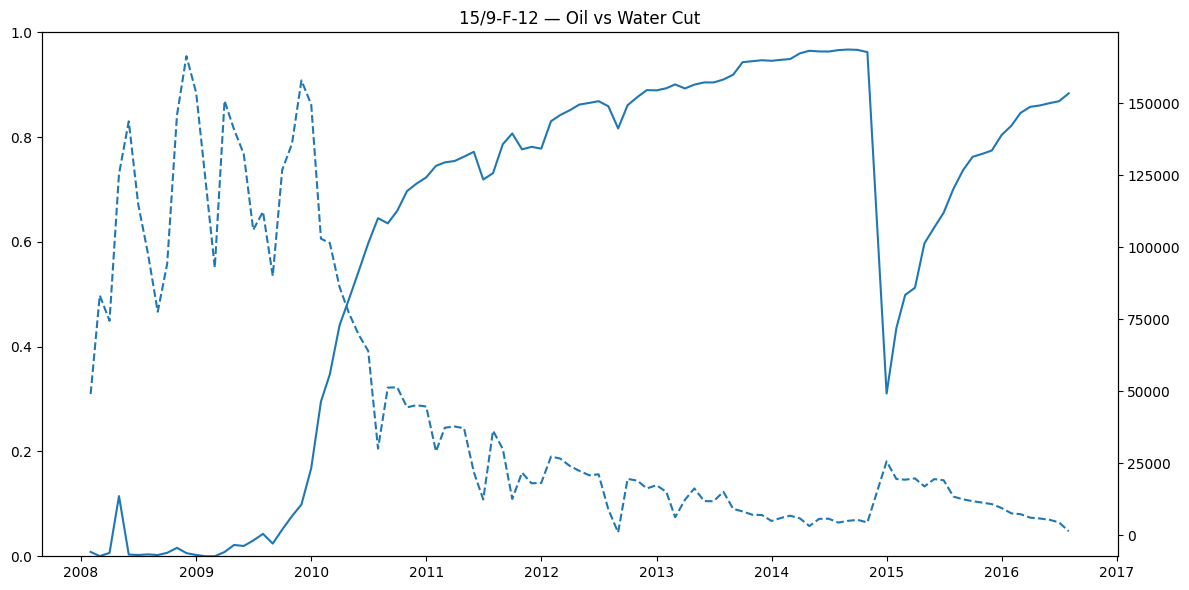

In [ ]:
"""
VannVakt — Volve NCS Data Cleaning
Input:  Volve production data.xlsx (Equinor open dataset)
Output: cleaned_vannvakt_data.csv
Author: Anuri Nwagbara

Cleaning steps:
1. Load raw monthly production data
2. Replace NULL strings with NaN
3. Convert numeric columns
4. Build date column
5. Filter to active producing months (oil, gas, or water > 0)
6. Calculate water cut = Water / (Oil + Water)
7. Save cleaned dataset
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load Volve production data
df = pd.read_excel(
    "Volve production data.xlsx",
    sheet_name="Monthly Production Data",
    skiprows=[1]
)

df = df.replace("NULL", pd.NA)

print("Dataset loaded")
print(f"Rows: {len(df)} | Wells: {df['Wellbore name'].nunique()}")
print(f"Years: {df['Year'].min()}–{df['Year'].max()}")

# ─────────────────────────────
# Prepare production dataset
# ─────────────────────────────

df_clean = df.copy()

for col in ["On Stream", "Oil", "Gas", "Water", "GI", "WI"]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean["Date"] = pd.to_datetime(
    dict(year=df_clean["Year"], month=df_clean["Month"], day=1),
    errors="coerce"
)

# Keep only months with production activity
df_clean["Active"] = (
    (df_clean["Oil"].fillna(0) > 0) |
    (df_clean["Gas"].fillna(0) > 0) |
    (df_clean["Water"].fillna(0) > 0)
)

df_prod = df_clean[df_clean["Active"]].copy()

# Water cut — main diagnostic signal
df_prod["Water_Cut"] = df_prod["Water"] / (
    df_prod["Oil"] + df_prod["Water"]
).replace(0, pd.NA)

print(f"Active rows: {len(df_prod)}")
print(f"Producing wells: {df_prod['Wellbore name'].nunique()}")

df_prod = df_prod[
    [
        "Date",
        "Wellbore name",
        "Year",
        "Month",
        "Oil",
        "Gas",
        "Water",
        "On Stream",
        "Water_Cut"
    ]
].copy()

df_prod.to_csv("cleaned_vannvakt_data.csv", index=False)
print("Saved cleaned dataset")

# ─────────────────────────────
# Water cut trends (all wells)
# ─────────────────────────────

df_plot = df_prod.sort_values(["Wellbore name", "Date"])

plt.figure(figsize=(14, 8))

for well in df_plot["Wellbore name"].unique():
    well_df = df_plot[df_plot["Wellbore name"] == well]
    plt.plot(well_df["Date"], well_df["Water_Cut"], linewidth=2)

plt.title("Water Cut — Volve Field")
plt.ylabel("Water Cut")
plt.xlabel("Date")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig("vannvakt_watercut.png", dpi=150)
plt.show()

# ─────────────────────────────
# 4.1 Build production signals
# ─────────────────────────────

df_detect = df_prod.sort_values(["Wellbore name", "Date"]).copy()

df_detect["WC_Change"] = df_detect.groupby("Wellbore name")["Water_Cut"].diff()
df_detect["Oil_Change"] = df_detect.groupby("Wellbore name")["Oil"].diff()

df_detect["WC_Rolling"] = df_detect.groupby("Wellbore name")["Water_Cut"].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# ─────────────────────────────
# 4.2 Detect breakthrough behaviour
# ─────────────────────────────

SPIKE = 0.10
SUSTAINED = 0.30

df_detect["Sudden"] = (
    (df_detect["WC_Change"] >= SPIKE) &
    (df_detect["Water_Cut"] >= 0.20) &
    (df_detect["Oil_Change"] < 0)
)

df_detect["Sustained"] = df_detect["WC_Rolling"] >= SUSTAINED
df_detect["Breakthrough"] = df_detect["Sudden"] | df_detect["Sustained"]

df_detect["Type"] = None
df_detect.loc[df_detect["Sudden"], "Type"] = "Sudden"
df_detect.loc[df_detect["Sustained"], "Type"] = "Sustained"

# ─────────────────────────────
# 4.3 Field-level summary
# ─────────────────────────────

events = df_detect[df_detect["Breakthrough"]]

print("\nDetected breakthrough events:")
print(
    events[
        ["Date", "Wellbore name", "Water_Cut", "WC_Change", "Oil_Change", "Type"]
    ].to_string(index=False)
)

# ─────────────────────────────
# 4.4 Single well diagnostic
# ─────────────────────────────

well = "15/9-F-12"
df_well = df_detect[df_detect["Wellbore name"] == well].sort_values("Date")

df_well["WC_Roll"] = df_well["Water_Cut"].rolling(3, min_periods=1).mean()
df_well["WC_Change"] = df_well["Water_Cut"].diff()
df_well["Oil_Change"] = df_well["Oil"].diff()

df_well["Anomaly"] = df_well["Breakthrough"]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Water cut behaviour
axes[0].plot(df_well["Date"], df_well["Water_Cut"], label="Water Cut")
axes[0].plot(df_well["Date"], df_well["WC_Roll"], linestyle="--", label="Rolling Avg")

axes[0].scatter(
    df_well[df_well["Anomaly"]]["Date"],
    df_well[df_well["Anomaly"]]["Water_Cut"],
    color="red"
)

axes[0].set_title(f"{well} — Diagnostic View")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True)

# Monthly change
axes[1].bar(
    df_well["Date"],
    df_well["WC_Change"],
    color=["red" if x else "steelblue" for x in df_well["Anomaly"]]
)

axes[1].axhline(SPIKE, linestyle="--")
axes[1].set_title("Monthly Δ Water Cut")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("vannvakt_diagnostic.png", dpi=150)
plt.show()

# ─────────────────────────────
# Oil vs water cut
# ─────────────────────────────

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_well["Date"], df_well["Water_Cut"], label="Water Cut")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(df_well["Date"], df_well["Oil"], linestyle="--", label="Oil Rate")

plt.title(f"{well} — Oil vs Water Cut")
plt.tight_layout()
plt.savefig("vannvakt_oil_vs_wc.png", dpi=150)
plt.show()